In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from tqdm import tqdm

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')

In [4]:
NUM_INPUT = 784
NUM_OUTPUT = 50
DT = 0.005         # 5 ms time step
T_MAX = 0.350      # 350 ms per image
EPOCHS = 1  #5
NUM_TRAIN_IMAGES = 10000 #60000
NUM_LABEL_IMAGES = 10000 #10000
NUM_TEST_IMAGES = 10000  #10000

In [5]:
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
train_images = mnist.data[:NUM_TRAIN_IMAGES] / 255.0
label_images = mnist.data[:NUM_LABEL_IMAGES] / 255.0
test_images = mnist.data[-NUM_TEST_IMAGES:] / 255.0

train_labels= mnist.target[:NUM_LABEL_IMAGES].astype(int) #for labelling
test_labels = mnist.target[-NUM_TEST_IMAGES:].astype(int) #for testing

In [6]:
def label(LR, epoch, weights):
    spike_counts = np.zeros((NUM_OUTPUT, 10))
    v_pre = np.zeros(NUM_INPUT)
    v_post = np.zeros(NUM_OUTPUT)

    n_adapt = np.zeros(NUM_OUTPUT)
    refractory_pre = np.zeros(NUM_INPUT)
    refractory_post = np.zeros(NUM_OUTPUT)
    wta_clamp = np.zeros(NUM_OUTPUT)
    
    for img_idx, img in tqdm(enumerate(label_images), total=len(label_images), desc="images"):
        
        v_pre.fill(0.0)
        v_post.fill(0.0)
        img_label = train_labels[img_idx]
        
        for t in np.arange(0, T_MAX, DT):
            # Input Neurons
            active_pre = refractory_pre <= 0
            v_pre[active_pre] += (DT / 0.03) * (-v_pre[active_pre] + img[active_pre] + 0.5)
            
            spikes_pre = v_pre >= 1.0
            v_pre[spikes_pre] = -1.0
            refractory_pre[spikes_pre] = 0.005
            refractory_pre -= DT
            
            # Output Neurons
            active_post = (refractory_post <= 0) & (wta_clamp <= 0)
            I_post = spikes_pre.astype(float) @ weights
            
            v_post[active_post] += (DT / 0.03) * (-v_post[active_post] + I_post[active_post] - n_adapt[active_post])
            n_adapt -= (DT / 1.0) * n_adapt
            
            spikes_post = v_post >= 1.0
            
            # Enforce Winner-Take-All during labeling
            if spikes_post.any():
                winner_idx = np.argmax(v_post)
                
                # Record the spike for the true winner only!
                spike_counts[winner_idx, img_label] += 1
                
                v_post[winner_idx] = 0.0
                refractory_post[winner_idx] = 0.005
                n_adapt[winner_idx] += 0.01
                
                wta_clamp[:] = 0.010
                wta_clamp[winner_idx] = 0.0
                v_post[wta_clamp > 0] = 0.0
                
            refractory_post -= DT
            wta_clamp -= DT
                
    assigned_labels = np.argmax(spike_counts, axis=1)
    np.save(f'./labels/assigned_labels_{LR}_{epoch+1}.npy', assigned_labels)
    print(f"labels saved: assigned_labels_{LR}_{epoch+1}.npy")
    return assigned_labels

In [9]:
def test(LR, weights, assigned_labels):
    
    correct_predictions = 0
    v_pre = np.zeros(NUM_INPUT)
    v_post = np.zeros(NUM_OUTPUT)

    n_adapt = np.zeros(NUM_OUTPUT)
    refractory_pre = np.zeros(NUM_INPUT)
    refractory_post = np.zeros(NUM_OUTPUT)
    wta_clamp = np.zeros(NUM_OUTPUT)

    for img_idx, img in tqdm(enumerate(test_images), total=len(test_images), desc="Testing SNN"):
        # Reset states for the new image
        v_pre.fill(0.0)
        v_post.fill(0.0)
        n_adapt.fill(0.0)
        refractory_pre.fill(0.0)
        refractory_post.fill(0.0)
        wta_clamp.fill(0.0)
        
        neuron_spikes = np.zeros(NUM_OUTPUT)
        
        for t in np.arange(0, T_MAX, DT):
            # Input Neurons (LIF)
            active_pre = refractory_pre <= 0
            v_pre[active_pre] += (DT / 0.03) * (-v_pre[active_pre] + img[active_pre] + 0.5)
            
            spikes_pre = v_pre >= 1.0
            v_pre[spikes_pre] = -1.0
            refractory_pre[spikes_pre] = 0.005
            refractory_pre -= DT
            
            # Output Neurons (ALIF)
            active_post = (refractory_post <= 0) & (wta_clamp <= 0)
            I_post = spikes_pre.astype(float) @ weights
            
            v_post[active_post] += (DT / 0.03) * (-v_post[active_post] + I_post[active_post] - n_adapt[active_post])
            n_adapt -= (DT / 1.0) * n_adapt
            
            spikes_post = v_post >= 1.0
            
            # Winner-Take-All
            if spikes_post.any():
                winner_idx = np.argmax(v_post)
                neuron_spikes[winner_idx] += 1
                
                v_post[winner_idx] = 0.0
                refractory_post[winner_idx] = 0.005
                n_adapt[winner_idx] += 0.01
                
                # Clamp other neurons
                wta_clamp[:] = 0.010
                wta_clamp[winner_idx] = 0.0
                v_post[wta_clamp > 0] = 0.0
                
            refractory_post -= DT
            wta_clamp -= DT
                                
        # Predict class based on the neuron with max spikes
        if neuron_spikes.sum() > 0:
            predicted_neuron = np.argmax(neuron_spikes)
            predicted_label = assigned_labels[predicted_neuron]
            
            if predicted_label == test_labels[img_idx]:
                correct_predictions += 1
            
    final_acc = (correct_predictions / len(test_images)) * 100
    print(f"Accuracy for LR={LR}: {final_acc:.2f}%")
    return final_acc

In [10]:
accuracies = np.zeros((len(learning_rates),EPOCHS))

for i, LR in enumerate(learning_rates):
    
    print(f'leaning rate = {LR}')
    # Initialize weights U(0, 1)
    weights = np.random.uniform(0, 1, (NUM_INPUT, NUM_OUTPUT))
    # Pre-allocate neuron states
    v_pre = np.zeros(NUM_INPUT)
    v_post = np.zeros(NUM_OUTPUT)
    n_adapt = np.zeros(NUM_OUTPUT)
    refractory_pre = np.zeros(NUM_INPUT)
    refractory_post = np.zeros(NUM_OUTPUT)
    wta_clamp = np.zeros(NUM_OUTPUT)
    
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch+1}:")
        for img_idx, img in tqdm(enumerate(train_images), total=len(train_images), desc="training: "):
            # Reset states for new image
            v_pre.fill(0.0)
            v_post.fill(0.0)
            
            # Input current proportional to pixel intensity
            I_in = img 
            
            for t in np.arange(0, T_MAX, DT):
                # --- Update Input Neurons (LIF) ---
                active_pre = refractory_pre <= 0
                v_pre[active_pre] += (DT / 0.03) * (-v_pre[active_pre] + I_in[active_pre] + 0.5)
                
                spikes_pre = v_pre >= 1.0
                v_pre[spikes_pre] = -1.0
                refractory_pre[spikes_pre] = 0.005
                refractory_pre -= DT
                
                # --- Update Output Neurons (ALIF) ---
                active_post = (refractory_post <= 0) & (wta_clamp <= 0)
                I_post = spikes_pre.astype(float) @ weights
                
                v_post[active_post] += (DT / 0.03) * (-v_post[active_post] + I_post[active_post] - n_adapt[active_post])
                n_adapt -= (DT / 1.0) * n_adapt
                
                spikes_post = v_post >= 1.0
                
                # --- Apply WTA and VDSP ---
                if spikes_post.any():
                    winner_idx = np.argmax(v_post) # Winner takes all
                    v_post[winner_idx] = 0.0
                    refractory_post[winner_idx] = 0.005
                    n_adapt[winner_idx] += 0.01
                    
                    # Clamp others
                    wta_clamp[:] = 0.010
                    wta_clamp[winner_idx] = 0.0
                    v_post[wta_clamp > 0] = 0.0
                    
                    # VDSP Weight Update for winner
                    v_pre_winner = v_pre
                    
                    # Potentiation (V_pre < 0)
                    pot_mask = v_pre_winner < 0
                    weights[pot_mask, winner_idx] += LR * (1.0 - weights[pot_mask, winner_idx]) * np.abs(v_pre_winner[pot_mask] + 1)
                    
                    # Depression (V_pre > 0)
                    dep_mask = v_pre_winner > 0
                    weights[dep_mask, winner_idx] -= LR * weights[dep_mask, winner_idx] * np.abs(v_pre_winner[dep_mask])
                    
                    # Clip weights (safety bound)
                    weights[:, winner_idx] = np.clip(weights[:, winner_idx], 0, 1)

                refractory_post -= DT
                wta_clamp -= DT
                                
        np.save(f'./weights/vdsp_weights_{LR}_{epoch+1}.npy', weights)
        print(f"Weights saved: vdsp_weights_{LR}_{epoch+1}.npy")
        assigned_label = label(LR, epoch, weights)
        acc = test(LR, weights, assigned_label)
        accuracies[i, epoch] = acc

leaning rate = 0.001
Epoch 1:


training: 100%|█████████████████████| 10000/10000 [01:15<00:00, 131.95it/s]


Weights saved: vdsp_weights_0.001_1.npy


images: 100%|███████████████████████| 10000/10000 [00:57<00:00, 174.92it/s]


labels saved: assigned_labels_0.001_1.npy


...

Weights saved: vdsp_weights_0.1_1.npy


images: 100%|███████████████████████| 10000/10000 [00:55<00:00, 179.92it/s]


labels saved: assigned_labels_0.1_1.npy


Testing SNN: 100%|██████████████████| 10000/10000 [00:59<00:00, 169.18it/s]

Accuracy for LR=0.1: 40.60%


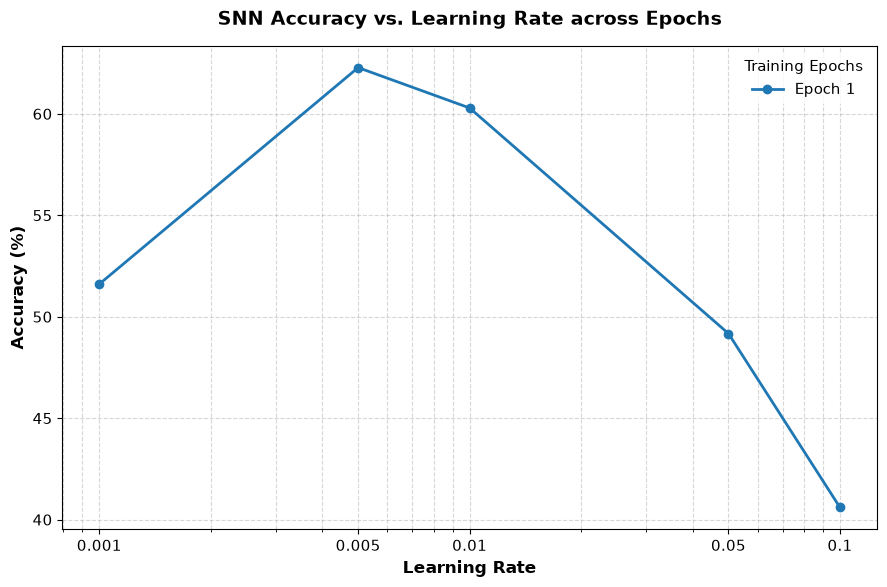

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the plot appearance
plt.figure(figsize=(9, 6))
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# 2. Plot a distinct line for each epoch across all learning rates
# Each row in `accuracies` corresponds to an LR, each column to an epoch
for epoch_idx in range(EPOCHS):
    epoch_accuracies = accuracies[:, epoch_idx]
    
    # Use different markers and line styles to clearly differentiate epochs
    plt.plot(
        learning_rates, 
        epoch_accuracies, 
        marker='o', 
        linewidth=2, 
        label=f'Epoch {epoch_idx + 1}'
    )

# 3. Format axes and labels mirroring paper figures
plt.xlabel('Learning Rate', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('SNN Accuracy vs. Learning Rate across Epochs', fontsize=14, fontweight='bold', pad=15)

# Use a logarithmic scale if your learning rates span orders of magnitude
plt.xscale('log')
plt.xticks(learning_rates, labels=[str(lr) for lr in learning_rates])

# Add grid lines for scannability
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Place the legend in a clean space
plt.legend(title='Training Epochs', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()

# 4. Display the updated figure
plt.show()